# Online Shopper Conversion Analysis


## Introduction

In this project, I will be analysing data about online shopping sessions in order to understand what factors are associated with the customer actually making a purchase.
The goal of the analysis will be to investigate patterns in the shoppers' behaviour and engagement with the website as well as the type of visitor and the source of the traffic that are connected to a successful purchase.
I will use Python for the data cleaning, exploratory analysis, and prediction parts of the project and I will build a dashboard using Tableau to highlight the key insights of the study.

### Research Question

What behavioural and contextual factors are associated with an online shopping session resulting in a purchase, and how effectively can such factors be used to predict purchase outcome?

## 1. Importing the Libraries

I will start the analysis by importing the libraries that I need for the analysis.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

I will now load the dataset as a dataframe and take a look at the data.

In [ ]:
df = pd.read_csv("online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Dataset Size

I will first check how many rows and columns the dataset contains.

In [73]:
df.shape

(12330, 18)

The dataset contains 12330 observations and 18 variables.

### Column Names

I will now check the names of the variables in the dataset.

In [74]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

### Data Types

I will now look at the data type of the variables.

In [75]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

### Dataset Information

I will use the info() function to see a summary of the data which will also help me understand the data types.

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

### Missing Values

Before proceeding with the analysis I will check if there are any missing values in the dataset.

In [77]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

### Duplicate Rows

I will check if there are any duplicate rows in the dataset.

In [78]:
df.duplicated().sum()

np.int64(125)

### Summary Statistics

I will now look at the descriptive statistics of the numerical variables in the dataset.

In [79]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 3. Understanding the Target Variable

The Revenue column indicates whether a shopping session resulted in a purchase. I will look at the data to see how the number of sessions with and without a purchase.

In [80]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [81]:
df["Revenue"].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

## 4. Data Cleaning

Before the start of the exploratory analysis, I will have a look at the dataset to see if there are any duplicate records and understand the categorical variables.
Since the dataset does not have any missing values, I will not be doing any missing value imputation.

### Checking Duplicate Records

As I have seen during the initial data inspection, there are some duplicate rows in the dataset. Before proceeding with the analysis, I will take a closer look at these records to understand the nature of the duplication.

In [82]:
df[df.duplicated()].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False


In [83]:
df[df.duplicated(keep=False)].shape

(201, 18)

In [84]:
df[df.duplicated(keep=False)]["Revenue"].value_counts()

Revenue
False    201
Name: count, dtype: int64

As seen in the initial data inspection, the dataset contains 125 duplicate rows. However, it does not seem like the dataset has a unique session ID or timestamp column that I could use to determine if the duplicated rows represent actual duplicate sessions or simply identical sessions.
The UCI documentation indicates that the dataset contains 12330 shopping sessions. With this in mind, I will retain the observations as they are for this analysis instead of removing the duplicate rows.
I will note the presence of duplicate rows as a limitation of this dataset.

## 5. Exploratory Data Analysis

In this section, I will look closer at the different variables in the dataset and compare sessions that resulted in a purchase to sessions that did not.
I will be examining the visitor characteristics, website engagement, traffic source, and shopping context.

In [85]:
df["Month"].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

In [86]:
df["VisitorType"].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [87]:
df["Weekend"].value_counts()

Weekend
False    9462
True     2868
Name: count, dtype: int64

In [88]:
df["TrafficType"].value_counts().sort_index()

TrafficType
1     2451
2     3913
3     2052
4     1069
5      260
6      444
7       40
8      343
9       42
10     450
11     247
12       1
13     738
14      13
15      38
16       3
17       1
18      10
19      17
20     198
Name: count, dtype: int64

### Overall Purchase Conversion

I will first look at the overall purchasing conversion.

In [89]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [90]:
conversion_rate = df["Revenue"].mean() * 100

print(f"Overall conversion rate: {conversion_rate:.2f}%")

Overall conversion rate: 15.47%


### Conversion Rate by Visitor Type

I would like to compare the conversion rates between different types of visitors.
Since the number of sessions is not equal between the different visitor categories, I will be looking at the conversion rate instead of the number of purchases.

In [91]:
visitor_conversion = df.groupby("VisitorType")["Revenue"].mean() * 100

visitor_conversion

VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

In [92]:
visitor_conversion.sort_values(ascending=False)

VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

### Conversion Rate by Weekend

I will now look at the conversion rate between weekend and weekday sessions.

In [93]:
weekend_conversion = df.groupby("Weekend")["Revenue"].mean() * 100

weekend_conversion

Weekend
False    14.891144
True     17.398884
Name: Revenue, dtype: float64

### Conversion Rate by Month

Since the number of sessions varies considerably between the different months, I will examine the conversion rate instead of the number of purchases.
I will also keep the months ordered chronologically.

In [94]:
monthly_conversion = df.groupby("Month")["Revenue"].mean() * 100

monthly_conversion

Month
Aug     17.551963
Dec     12.507238
Feb      1.630435
Jul     15.277778
June    10.069444
Mar     10.068170
May     10.850178
Nov     25.350233
Oct     20.947177
Sep     19.196429
Name: Revenue, dtype: float64

In [95]:
monthly_conversion = df.groupby("Month")["Revenue"].mean() * 100

month_order = [
    "Feb", "Mar", "May", "June", "Jul",
    "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_conversion = monthly_conversion.reindex(month_order)

monthly_conversion

Month
Feb      1.630435
Mar     10.068170
May     10.850178
June    10.069444
Jul     15.277778
Aug     17.551963
Sep     19.196429
Oct     20.947177
Nov     25.350233
Dec     12.507238
Name: Revenue, dtype: float64

### Conversion Rate by Traffic Type

I will look at the conversion rate between the different traffic types. Since some categories contain a very small number of sessions, I will also take the number of sessions into account when interpreting the results.

In [96]:
traffic_analysis = df.groupby("TrafficType").agg(
    Sessions=("Revenue", "size"),
    Purchases=("Revenue", "sum"),
    Conversion_Rate=("Revenue", "mean")
)

traffic_analysis["Conversion_Rate"] = traffic_analysis["Conversion_Rate"] * 100

traffic_analysis.sort_values("Sessions", ascending=False)

,Sessions,Purchases,Conversion_Rate
TrafficType,,,
2,3913,847,21.645796
1,2451,262,10.689514
3,2052,180,8.771930
4,1069,165,15.434986
13,738,43,5.826558
10,450,90,20.000000
6,444,53,11.936937
8,343,95,27.696793
5,260,56,21.538462


### Visitor Type and Purchase Behaviour

It seems that there are some differences in the conversion rates between the different visitor types. I will now look at the association between visitor type and purchase using a contingency table.
The contingency table will show the number of purchasing and non-purchasing sessions for the different visitor types.

In [97]:
visitor_table = pd.crosstab(df["VisitorType"], df["Revenue"])

visitor_table

Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [98]:
visitor_table_percent = pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
) * 100

visitor_table_percent

Revenue,False,True
VisitorType,,
New_Visitor,75.088548,24.911452
Other,81.176471,18.823529
Returning_Visitor,86.067671,13.932329


In [99]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(visitor_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 135.25
p-value: 0.0000


### Visitor Type Results

The chi-square test produced a p-value below 0.05 which indicates that there is an association between the visitor type and the purchase outcome.
New visitors had a higher conversion rate (24.91%) than returning visitors (13.93%). However, the effect size was relatively small.
This indicates that the visitor type is correlated with the purchase outcome, but it is unlikely to be the sole determinant of a successful purchase.

### Weekend and Purchase Behaviour

The descriptive analysis indicated a difference in the conversion rates between weekday and weekend sessions.
I will now use a contingency table and run a chi-square test to see if there is an association between the weekend status and the purchase outcome.

In [100]:
weekend_table = pd.crosstab(df["Weekend"], df["Revenue"])

weekend_table

Revenue,False,True
Weekend,,
False,8053,1409
True,2369,499


In [101]:
weekend_table_percent = pd.crosstab(
    df["Weekend"],
    df["Revenue"],
    normalize="index"
) * 100

weekend_table_percent

Revenue,False,True
Weekend,,
False,85.108856,14.891144
True,82.601116,17.398884


In [102]:
chi2, p_value, dof, expected = chi2_contingency(weekend_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 10.39
p-value: 0.0013


### Weekend Results

The chi-square test produced a p-value below 0.05 which indicates that there is an association between the weekend status and the purchase outcome.
Weekend sessions had a conversion rate of 17.40% compared to 14.89% for weekdays sessions, but the effect size was very small.
This indicates that while weekend status might be a factor in the purchase decision, it is unlikely to be a major contributor.

### Measuring the Strength of the Associations

The chi-square test is useful for determining if there is an association, but it does not indicate how strong the association is.
I will calculate an effect size to get a better understanding of how strong the associations are.

In [103]:
from scipy.stats.contingency import association

visitor_effect = association(visitor_table, method="cramer")

print(f"Cramer's V for Visitor Type: {visitor_effect:.3f}")

weekend_effect = association(weekend_table, method="cramer")

print(f"Cramer's V for Weekend: {weekend_effect:.3f}")

Cramer's V for Visitor Type: 0.105
Cramer's V for Weekend: 0.029


### Effect Size Results

Cramer's V was used to understand the strength of the association between the categorical variables and the purchase outcome.
The Cramer's V value for Visitor Type was 0.105 which indicates that the association between the visitor type and the purchase outcome is small.
For the Weekend, the Cramer's V value was 0.029 which indicates that the association is very small.
These results indicate that statistical significance does not necessarily translate into a large effect. Visitor type seems to have a stronger association with the purchase than the weekend, but both variables should be considered in conjunction with other factors.

In [104]:
behavior_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

behavior_summary = df.groupby("Revenue")[behavior_columns].mean().T

behavior_summary

Revenue,False,True
Administrative,2.117732,3.393606
Administrative_Duration,73.740111,119.483244
Informational,0.451833,0.786164
Informational_Duration,30.236237,57.611427
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


In [105]:
from scipy.stats import ttest_ind

no_purchase = df[df["Revenue"] == False]
purchase = df[df["Revenue"] == True]

for column in behavior_columns:
    t_stat, p_value = ttest_ind(
        no_purchase[column],
        purchase[column],
        equal_var=False
    )
    
    print(f"{column}: p-value = {p_value:.4f}")

Administrative: p-value = 0.0000
Administrative_Duration: p-value = 0.0000
Informational: p-value = 0.0000
Informational_Duration: p-value = 0.0000
ProductRelated: p-value = 0.0000
ProductRelated_Duration: p-value = 0.0000
BounceRates: p-value = 0.0000
ExitRates: p-value = 0.0000
PageValues: p-value = 0.0000


In [106]:
ttest_results = []

for column in behavior_columns:
    t_stat, p_value = ttest_ind(
        no_purchase[column],
        purchase[column],
        equal_var=False
    )
    
    no_purchase_mean = no_purchase[column].mean()
    purchase_mean = purchase[column].mean()
    
    ttest_results.append({
        "Variable": column,
        "No Purchase Mean": no_purchase_mean,
        "Purchase Mean": purchase_mean,
        "Difference": purchase_mean - no_purchase_mean,
        "p-value": p_value
    })

ttest_results = pd.DataFrame(ttest_results)

ttest_results

,Variable,No Purchase Mean,Purchase Mean,Difference,p-value
0,Administrative,2.117732,3.393606,1.275874,4.970386e-43
1,Administrative_Duration,73.740111,119.483244,45.743133,2.173197e-20
2,Informational,0.451833,0.786164,0.334331,2.089108e-19
3,Informational_Duration,30.236237,57.611427,27.375189,4.772254e-11
4,ProductRelated,28.714642,48.210168,19.495526,8.834785e-43
5,ProductRelated_Duration,1069.987809,1876.209615,806.221806,2.173791e-45
6,BounceRates,0.025317,0.005117,-0.020200,2.587228e-253
7,ExitRates,0.047378,0.019555,-0.027823,0.000000e+00
8,PageValues,1.975998,27.264518,25.288520,9.610670e-174


### Behavioural Results

The Welch's t-tests indicated that there are statistically significant differences between purchasing and non-purchasing sessions with respect to all nine behavioural variables.
The purchasing sessions had significantly higher mean values for administrative, informational, and product-related page views and duration as well as significantly lower mean values for bounce rate and exit rate.
The largest mean difference was found for product-related pageviews, duration, and PageValues. However, statistical significance does not indicate that a given variable is a strong predictor of a purchase; the variables might also be correlated with each other, and the analysis reflects associations rather than causation.
These results provide a foundation for further analysis and predictive modelling.

## 6. Visualizing Key Behavioural Patterns

The statistical analysis indicated some key differences between purchasing and non-purchasing sessions. I will visualize a few of the interesting patterns to make the differences more apparent.

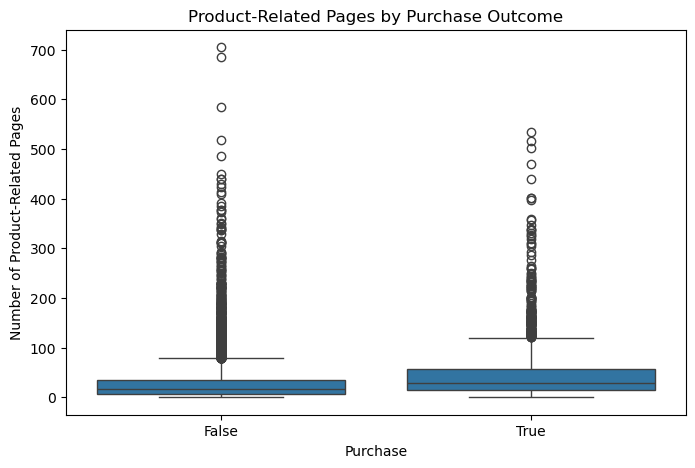

In [107]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated"
)

plt.title("Product-Related Pages by Purchase Outcome")
plt.xlabel("Purchase")
plt.ylabel("Number of Product-Related Pages")

plt.show()

### Product-Related Engagement

The boxplot indicates that purchasing sessions tend to have more product-related pageviews than non-purchasing sessions. The distribution of the purchasing sessions is shifted towards the higher values, although there are also many high-value outliers in the non-purchasing sessions.
This is consistent with the earlier findings about the product-related pageviews being associated with purchase outcome.

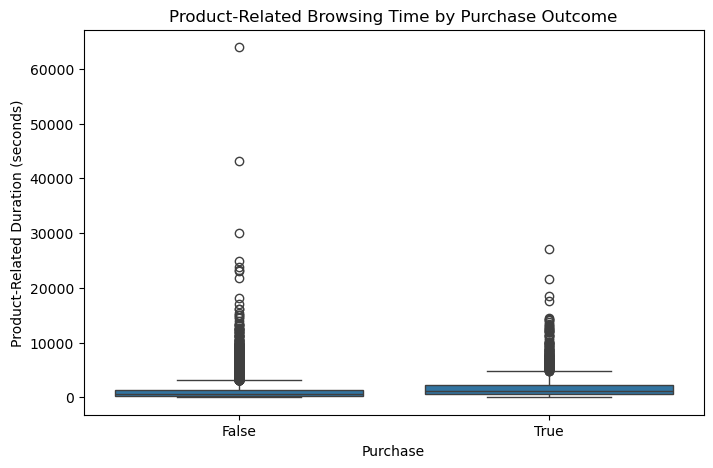

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration"
)

plt.title("Product-Related Browsing Time by Purchase Outcome")
plt.xlabel("Purchase")
plt.ylabel("Product-Related Duration (seconds)")

plt.show()

### Product-Related Browsing Time

The purchasing sessions generally have higher values for the product-related browsing time than the non-purchasing sessions, but the large number of outliers indicates that increased engagement with the product-related pages does not guarantee a purchase.
This is consistent with the earlier findings about the product-related browsing time being associated with the purchase outcome.

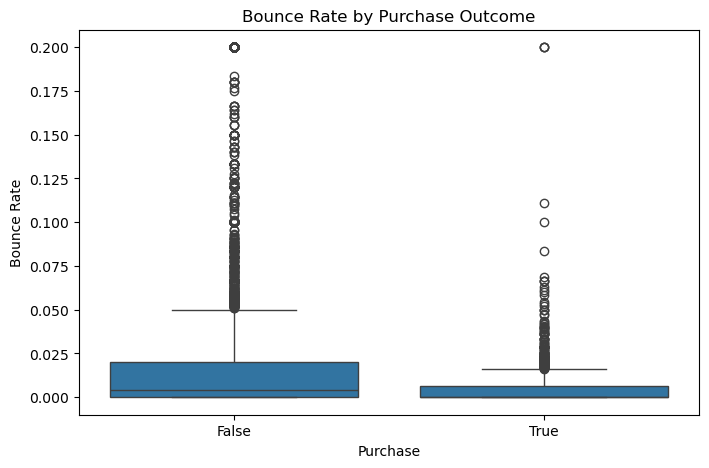

In [109]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="BounceRates"
)

plt.title("Bounce Rate by Purchase Outcome")
plt.xlabel("Purchase")
plt.ylabel("Bounce Rate")

plt.show()

### Bounce Rate

The boxplot indicates that purchasing sessions generally have lower bounce rates than non-purchasing sessions. The purchasing group is more tightly distributed around zero while the non-purchasing sessions show a wider distribution and more high-value observations.
This is consistent with the earlier findings about the bounce rate being associated with the purchase outcome.
However, the considerable overlap and the high-value outliers indicate that while the bounce rate might be a factor in some sessions, it cannot explain the purchase outcome on its own.

## 7. Predictive Analysis

The exploratory analysis indicated that there are several behavioural and contextual factors that are associated with the purchase outcome. In this section, I will be determining if these factors can be used to predict whether a shopping session will result in a purchase.
A classification model will be used since the target variable, Revenue, has two possible outcomes (purchase and no purchase).

In [110]:
features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

X = df[features]
y = df["Revenue"]

X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,Feb,3,3,1,4,Returning_Visitor,True


### Feature Selection for Predictive Modelling

PageValues was included in the exploratory analysis because it is part of the original dataset and shows a strong difference between purchasing and non-purchasing sessions.

However, I excluded PageValues from the predictive models because its definition is closely related to the value of pages visited before an e-commerce transaction. Including this variable when predicting purchase outcome could introduce target-related information and make the model appear more predictive than it would be using information that is available independently of the outcome.

For this reason, I retained PageValues for descriptive analysis but excluded it from the predictive feature set.

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (9864, 16)
Test set: (2466, 16)


In [112]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Revenue
False    84.529603
True     15.470397
Name: proportion, dtype: float64

Test target distribution:
Revenue
False    84.509327
True     15.490673
Name: proportion, dtype: float64


### Train-Test Split

The dataset was split into 80% training data and 20% testing data.
Stratified sampling was used to ensure that the proportions of purchasing and non-purchasing sessions were the same in the training and test sets. The training set contains 9864 sessions and the test set contains 2466 sessions.
The purchase rate is approximately 15.47% in the training set and 15.49% in the test set which indicates that the target distribution was maintained during the split.

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [115]:
y_pred = model.predict(X_test)

y_pred[:10]

array([False, False, False, False, False, False, False, False, False,
       False])

In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Accuracy:  0.845
Precision: 0.481
Recall:    0.034
F1 Score:  0.064
ROC-AUC:   0.734


[[2070   14]
 [ 369   13]]


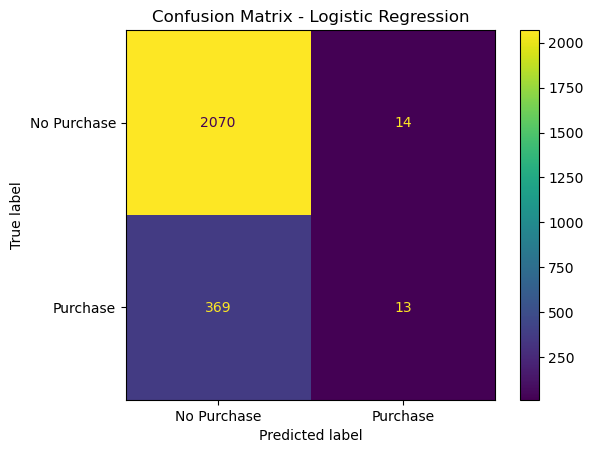

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [118]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:20])

print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

print("Predictions at 0.5 threshold:", (y_prob >= 0.5).sum())

[0.03617471 0.08345651 0.19552683 0.00553501 0.02674282 0.05691509
 0.09874348 0.28692956 0.30774544 0.14203617 0.39658976 0.28372057
 0.10729724 0.00373881 0.28672231 0.18415935 0.38273211 0.18915211
 0.28601026 0.25838704]
Minimum probability: 0.00010184469416700954
Maximum probability: 0.7342492259871641
Mean probability: 0.15782823350051106
Predictions at 0.5 threshold: 27


### Comparing a Second Classification Model

Logistic Regression provides a useful baseline since it is relatively simple and intuitive to use. However, the relationships between shopping behaviour and purchase outcome might not be purely linear.
To see if a different approach provides better results, I will be comparing the Logistic Regression model with a Random Forest classifier.
The Random Forest model has the ability to find patterns that are not linear. The same features, training data, and testing data will be used for both models to ensure that the comparison is fair.

In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [121]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [122]:
rf_pred = rf_model.predict(X_test)

In [123]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [124]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy:  {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall:    {rf_recall:.3f}")
print(f"F1 Score:  {rf_f1:.3f}")
print(f"ROC-AUC:   {rf_roc_auc:.3f}")

Accuracy:  0.849
Precision: 0.565
Recall:    0.102
F1 Score:  0.173
ROC-AUC:   0.749


### Model Comparison

The Random Forest produced slightly better results than Logistic Regression for all five evaluation metrics.
ROC-AUC increased from 0.734 (Logistic Regression) to 0.749 (Random Forest), while recall increased from 0.034 to 0.102, and the F1 score increased from 0.064 to 0.173.
While Random Forest provided an improvement, the recall was still relatively low at the default classification threshold. This means that both models failed to identify a substantial number of purchasing sessions.
It seems that there are patterns in session characteristics that correlate with the purchase outcome, but the predictive power of the models is still relatively low.

### XGBoost

XGBoost was added as a third classification model to see if a gradient boosting approach could provide any additional insights.
The model is compared using the same training and testing datasets and the same feature set as the previous models. This will allow the performance of Logistic Regression, Random Forest, and XGBoost to be compared more directly.
I am using a relatively simple XGBoost configuration rather than extensive hyperparameter tuning since the purpose of this project is to compare modelling approaches rather than optimize a production model.

In [125]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [126]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [127]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [128]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print(f"Accuracy:  {xgb_accuracy:.3f}")
print(f"Precision: {xgb_precision:.3f}")
print(f"Recall:    {xgb_recall:.3f}")
print(f"F1 Score:  {xgb_f1:.3f}")
print(f"ROC-AUC:   {xgb_roc_auc:.3f}")

Accuracy:  0.844
Precision: 0.483
Recall:    0.076
F1 Score:  0.131
ROC-AUC:   0.773


In [129]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.844688,0.481481,0.034031,0.063570,0.733983
1,Random Forest,0.848743,0.565217,0.102094,0.172949,0.748793
2,XGBoost,0.844282,0.483333,0.075916,0.131222,0.772650


### Final Model Comparison

The three classification models produced different results.
XGBoost achieved the highest ROC-AUC score (0.773) compared to Random Forest (0.749) and Logistic Regression (0.734). This indicates that XGBoost had the best overall ability to distinguish between purchasing and non-purchasing sessions based on predicted probabilities.
However, Random Forest achieved the highest precision, recall, and F1 score at the default classification threshold of 0.50.
All three models produced relatively low recall at the default threshold which indicates that a substantial number of purchasing sessions were classified as non-purchases. This is partly due to the imbalanced target (only about 15.5% of sessions resulted in a purchase).
These results indicate that the choice of evaluation metric and classification threshold has a considerable impact on the results. For this reason, accuracy would not provide a complete assessment of the models.

### Classification Threshold Analysis

The previous models used the default probability threshold of 0.50 to classify a session as a purchase or a non-purchase.
Since the purchase class represents a minority of sessions, the default threshold might result in many purchasing sessions being classified as non-purchases.
To explore this trade-off, I will evaluate the XGBoost model at several probability thresholds. This will indicate how precision, recall, and F1 score are affected when the threshold is lowered.
The purpose is not to select a threshold solely on the basis of the highest metric, but to understand the trade-off between identifying more potential purchases and obtaining more false positive predictions.

In [130]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

threshold_results = []

for threshold in thresholds:
    threshold_pred = (xgb_prob >= threshold)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_pred),
        "Recall": recall_score(y_test, threshold_pred),
        "F1 Score": f1_score(y_test, threshold_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.5,0.483333,0.075916,0.131222
1,0.4,0.462963,0.196335,0.275735
2,0.3,0.360656,0.345550,0.352941
3,0.2,0.312339,0.636126,0.418966
4,0.1,0.242446,0.882199,0.380361


In [131]:
threshold_results["Predicted Purchases"] = [
    (xgb_prob >= threshold).sum()
    for threshold in thresholds
]

threshold_results

,Threshold,Precision,Recall,F1 Score,Predicted Purchases
0,0.5,0.483333,0.075916,0.131222,60
1,0.4,0.462963,0.196335,0.275735,162
2,0.3,0.360656,0.345550,0.352941,366
3,0.2,0.312339,0.636126,0.418966,778
4,0.1,0.242446,0.882199,0.380361,1390


### Threshold Analysis Results

The threshold analysis indicates a trade-off between precision and recall. Lowering the classification threshold increases the number of sessions classified as potential purchases and has a considerable impact on the recall, but it also decreases the precision.
At the default threshold of 0.50, the recall was 7.6%. Lowering the threshold to 0.20 increased the recall to 63.6%, while the precision decreased from 48.3% to 31.2%. At a threshold of 0.10, the recall increased to 88.2%, but the precision decreased to 24.2%.
These results indicate that the choice of classification threshold can have a considerable impact on the model's behaviour. However, these threshold results are exploratory since they were evaluated on the test set. A separate validation approach would be needed to select a threshold without using the test data for model decisions.

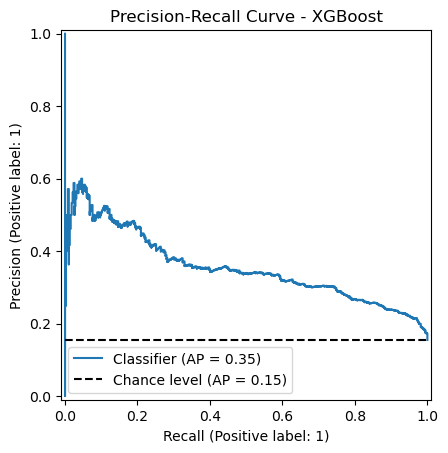

In [132]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_prob,
    plot_chance_level=True
)

plt.title("Precision-Recall Curve - XGBoost")
plt.show()

### Precision-Recall Curve

The precision-recall curve indicates the trade-off between identifying more purchasing sessions and maintaining precision.
As the recall increases, precision generally decreases. This means that identifying a larger proportion of potential purchasers comes at the cost of having more false positive predictions.
The XGBoost model achieved an Average Precision of approximately 0.35, which is above the overall purchase prevalence of approximately 15.5%. This indicates that the model's ranking of positive sessions contains information beyond the class prevalence, although there is still a substantial precision-recall trade-off.
This indicates that it is important to select a classification threshold based on the intended business use rather than relying solely on the default threshold of 0.50.

### XGBoost Feature Importance

The predictive models indicated that the characteristics of a session contain useful information for distinguishing purchasing and non-purchasing sessions.
To better understand what the XGBoost model is using, feature importance will be examined. This provides an indication of which transformed features contributed the most to the model's predictions.
Since categorical variables were one-hot encoded, some original variables are represented by multiple transformed features.

In [133]:
# Get the feature names after preprocessing
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Get the feature importance values from XGBoost
importance_values = xgb_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
72,numeric__ExitRates,0.065087
7,categorical__Month_Nov,0.052309
62,categorical__VisitorType_Returning_Visitor,0.041990
70,numeric__ProductRelated_Duration,0.031330
60,categorical__VisitorType_New_Visitor,0.029007
42,categorical__TrafficType_3,0.028939
9,categorical__Month_Sep,0.026609
71,numeric__BounceRates,0.024985
12,categorical__OperatingSystems_3,0.024360
47,categorical__TrafficType_8,0.021459


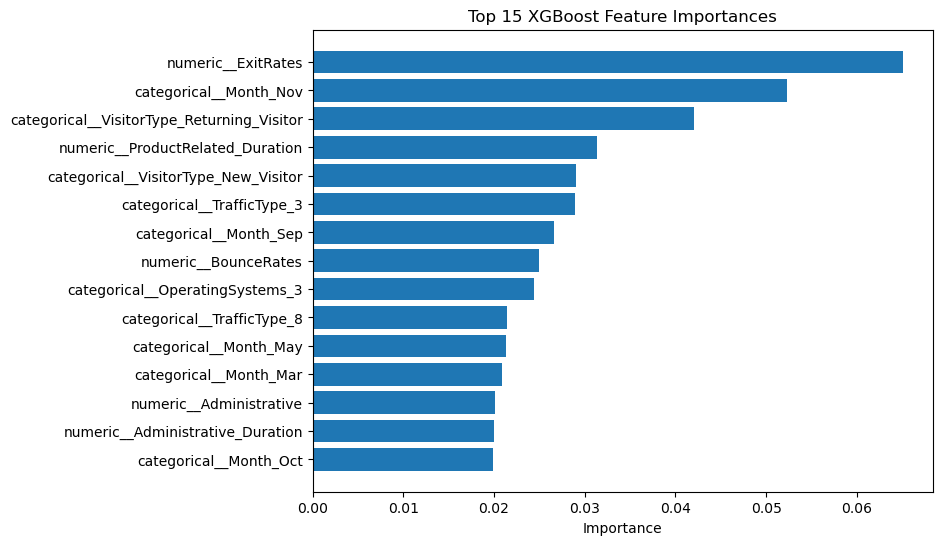

In [134]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")

plt.show()

In [135]:
original_features = numeric_features + categorical_features

def get_original_feature(feature_name):
    feature_name = feature_name.replace("numeric__", "")
    feature_name = feature_name.replace("categorical__", "")
    
    for original in original_features:
        if feature_name == original or feature_name.startswith(original + "_"):
            return original
    
    return feature_name

feature_importance["Original_Feature"] = (
    feature_importance["Feature"].apply(get_original_feature)
)

grouped_importance = (
    feature_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

Original_Feature
Month               0.213743
TrafficType         0.199651
Browser             0.107833
OperatingSystems    0.076613
Region              0.072348
VisitorType         0.070997
ExitRates           0.065087
ProductRelated      0.048438
Administrative      0.040149
Weekend             0.031901
Informational       0.029278
BounceRates         0.024985
SpecialDay          0.018979
Name: Importance, dtype: float32

### Feature Importance Results

The XGBoost feature importance analysis indicates that several behavioural and contextual variables contributed to the model's predictions. Among the individual transformed features, ExitRates had the highest importance. When one-hot encoded features were grouped back to their original variables, Month and TrafficType had the highest overall importance.
These results are broadly consistent with the earlier exploratory analysis. For example, purchasing sessions had lower average exit and bounce rates, while they also showed higher product-related browsing activity.
The importance of Month and VisitorType also indicates that contextual characteristics of a session contributed to the model's predictions.
However, feature importance should not be interpreted as indicating causation or a direct measure of business impact. It indicates which variables were useful to the XGBoost model for distinguishing between purchasing and non-purchasing sessions. It does not indicate if a variable increases or decreases the probability of purchase.
For categorical variables, multiple one-hot encoded features were combined to indicate the importance of the original variable. Therefore, these results should be interpreted as a general indication of which variables the model used rather than a definitive ranking of the factors that cause conversion.

## 8. Business Insights and Recommendations

The analysis identified several behavioural and contextual patterns that are associated with online purchase outcomes.
The results can be summarized in four key areas of website engagement, visitor type, traffic sources, and shopping context.
These findings describe associations that were observed in this dataset and should not be interpreted as proof of causal relationships.

### 8.1 Key Business Insights

Based on the exploration and predictive modelling, several patterns were identified in the shopping sessions.
1. Product-related engagement is associated with conversion
Purchasing sessions had higher average numbers of product-related pageviews and substantially longer product-related browsing time than non-purchasing sessions. This indicates that product-related engagement is an important characteristic of sessions that result in a purchase.
2. Lower bounce and exit rates are associated with purchasing sessions
Purchasing sessions had lower average bounce and exit rates than non-purchasing sessions. Bounce rate and exit rate also contributed to the predictive models, with ExitRates having the highest individual feature importance in the XGBoost model.
3. Visitor type is associated with purchase outcome
New visitors had a conversion rate of 24.91%, compared with 13.93% for returning visitors. The chi-square test provided evidence of an association between visitor type and purchase outcome, but the effect size was relatively small.
4. Conversion varies across traffic sources
Conversion rates differed across traffic types. However, some traffic categories contained very few sessions, so their conversion rates should not be used in isolation when making business decisions. Session volume should also be taken into account.
5. Shopping context also matters
Conversion rates varied across months, with November showing a particularly high observed conversion rate in this dataset. Weekend sessions had a conversion rate of 17.40%, compared with 14.89% for weekday sessions, although the effect size for weekend status was very small.
6. Predictive modelling shows that conversion can be estimated from session characteristics
The XGBoost model achieved the highest ROC-AUC among the three models tested, with a score of 0.773. However, the models had relatively low recall at the default classification threshold. This means that the models should be seen as tools for identifying patterns and potential purchasing sessions rather than as perfect purchase predictors.

### 8.2 Business Recommendations

The analysis indicates several areas that an online retailer could further investigate.

1. Investigate the product browsing experience

Since purchasing sessions showed higher product-related engagement, the retailer could investigate the product browsing journey to see what pages, navigation paths, and product interactions are associated with successful sessions. These findings could then be used to further test and optimize the browsing experience.

2. Investigate high-exit sessions and site areas

Exit rate was the most important individual feature in the XGBoost model, while purchasing sessions had lower average exit rates. The retailer could investigate sessions with high exit rates and use more detailed page-level analytics to identify where visitors are leaving and whether navigation, product information, calls to action, or the checkout journey could be improved.

3. Develop different strategies for new and returning visitors

The conversion rates were different for new and returning visitors. The impact of the marketing campaigns and the website experience could be evaluated separately for new and returning visitors instead of considering all the visitors in one group.

4. Evaluate traffic sources based on the mixture of volume and conversion

It is recommended to evaluate the different traffic sources based on both the volume of sessions and conversion. A traffic types that has a high conversion rate but also few sessions will not always be as important as the traffic types that produces more sessions with a lower conversion rate.

5. Use predictive scores as prioritization tool

The classification models could be utilized to prioritize the sessions that have higher predicted chances to purchase. However, the classification score should be defined depending on the business goal, and the model should be validated with separate validation data before the model is used in practice.

### 8.3 Limitations

There are a number of limitations to this analysis.

Firstly, there were 125 duplicated rows in the dataset, but there was no unique session identifier, so it is not possible to confirm whether these are accidental duplicates or separate sessions with identical recorded characteristics.

Secondly, the analysis is based on associations within the data, not causal relationships.

Thirdly, some traffic types had very few sessions, so their conversion rate estimates may not be reliable.

The predictive models were trained on a single train/test split, without extensive parameter tuning or cross-validation, so the model performance reported should not be taken as a guarantee of performance on unseen data.

Finally, PageValues was excluded from the predictive models due to its potential target-related information, although it was used in the descriptive analysis.